# Psychometric and chronometric curves by LDA 1 bin

Pools all sessions within each of the 5 pre-computed LDA 1 bins (`binned1` column from `mouse_LDA_5_bins_cut19-06-2026`) and plots one averaged psychometric + chronometric curve per bin, split by bias block (0.2 / 0.5 / 0.8), mirroring the per-session/per-state style in `load_states.ipynb`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import pearsonr, spearmanr
from pathlib import Path
from one.api import ONE

one = ONE(mode='remote')

prefix = '/Users/ineslaranjeira/Documents/Repositories/representation_learning_variability/paper-individuality/'

In [2]:
lda = pd.read_pickle(prefix + 'clustering/mouse_LDA_5_bins_cut19-06-2026').rename(columns={0: 'lda_1'})
states_df = pd.read_parquet(prefix + 'GLM-HMM/merged_behavioral_and_states.pqt')

# choice_right derivation matches engaged.py's plot_psychometric_curves (see load_states.ipynb):
# contrastLeft is NaN => stimulus was on the right, so a rewarded trial means the animal went right;
# contrastRight is NaN => stimulus was on the left, so an unrewarded trial means the animal went right.
right_correct = states_df['contrastLeft'].isna() & (states_df['rewarded'] == 1)
right_incorrect = states_df['contrastRight'].isna() & (states_df['rewarded'] == -1)
states_df['choice_right'] = (right_correct | right_incorrect).astype(int)
states_df['block'] = states_df['probabilityLeft']

# Boolean filtering (not merge) preserves states_df's original row order within each eid group,
# which is required later to align trial_idx with the ONE-fetched trial order for RT.
bin_map = lda.set_index('session')['binned1']
lda1_map = lda.set_index('session')['lda_1']
mouse_map = lda.set_index('session')['mouse_name']

trials = states_df[states_df['eid'].isin(lda['session'])].copy()
trials['lda_bin'] = trials['eid'].map(bin_map)
trials['lda_1'] = trials['eid'].map(lda1_map)
trials['mouse_name'] = trials['eid'].map(mouse_map)
trials['trial_idx'] = trials.groupby('eid').cumcount()

print(f"LDA sessions: {lda['session'].nunique()}")
print(f"Sessions with GLM-HMM/behavioral data: {trials['eid'].nunique()} / {lda['session'].nunique()}")
print()
print(trials.groupby('lda_bin', observed=True)['eid'].nunique().rename('n_sessions'))

LDA sessions: 248
Sessions with GLM-HMM/behavioral data: 244 / 248

lda_bin
(-7.474, -4.154]    47
(-4.154, -0.851]    81
(-0.851, 2.452]     58
(2.452, 5.755]      44
(5.755, 9.058]      14
Name: n_sessions, dtype: int64


## Fetch reaction times (cached to disk)

No local file has per-trial reaction times aligned to `states_df` (see `load_states.ipynb`), so `firstMovement_times - stimOn_times` is fetched live via `ONE`, one session at a time (~12s/session first run). Results are cached to `rt_cache.pqt` so repeat runs are instant. Row order per session was validated against raw ONE `feedbackType`/contrasts in `load_states.ipynb` to match `states_df` exactly.

In [3]:
RT_CACHE_PATH = Path(prefix + 'GLM-HMM/rt_cache.pqt')


def load_rt_cache():
    if RT_CACHE_PATH.exists():
        return pd.read_parquet(RT_CACHE_PATH)
    return pd.DataFrame(columns=['eid', 'trial_idx', 'reaction_time'])


def fetch_reaction_time(eid):
    """firstMovement_times - stimOn_times, aligned 1:1 with states_df rows for this eid."""
    trials_obj = one.load_object(eid, 'trials', collection='alf')
    return trials_obj['firstMovement_times'] - trials_obj['stimOn_times']


def build_rt_cache(eids, trials_df):
    cache = load_rt_cache()
    cached_eids = set(cache['eid'].unique())
    missing = [e for e in eids if e not in cached_eids]
    print(f"{len(missing)} / {len(eids)} sessions need fetching ({len(cached_eids)} already cached)")

    new_rows = []
    for i, eid in enumerate(missing):
        try:
            rt = fetch_reaction_time(eid)
        except Exception as e:
            print(f"  Skipping {eid}: fetch failed ({e})")
            continue

        n_expected = (trials_df['eid'] == eid).sum()
        if len(rt) != n_expected:
            print(f"  Skipping {eid}: trial count mismatch (ONE={len(rt)} vs states_df={n_expected})")
            continue

        new_rows.append(pd.DataFrame({'eid': eid, 'trial_idx': np.arange(len(rt)), 'reaction_time': rt}))

        if (i + 1) % 20 == 0 or (i + 1) == len(missing):
            print(f"  fetched {i + 1} / {len(missing)}")
            pd.concat([cache] + new_rows, ignore_index=True).to_parquet(RT_CACHE_PATH)

    if new_rows:
        cache = pd.concat([cache] + new_rows, ignore_index=True)
        cache.to_parquet(RT_CACHE_PATH)
    return cache

In [4]:
rt_cache = build_rt_cache(trials['eid'].unique(), trials)
print(f"RT cache: {rt_cache['eid'].nunique()} sessions, {len(rt_cache)} trials")

244 / 244 sessions need fetching (0 already cached)


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


...

/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


/opt/anaconda3/envs/iblenv/lib/python3.10/site-packages/one/util.py:428: ALFWarning: Multiple revisions: "", "2025-03-03"
  warnings.warn(f'Multiple revisions: {rev_list}', alferr.ALFWarning)


  fetched 244 / 244


/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_62184/3337173804.py:39: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([cache] + new_rows, ignore_index=True).to_parquet(RT_CACHE_PATH)
/var/folders/nt/d2j3zp9d1xzb8wgfrw81j0c40000gn/T/ipykernel_62184/3337173804.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cache = pd.concat([cache] + new_rows, ignore_index=True)


RT cache: 243 sessions, 153874 trials


In [5]:
trials = trials.merge(rt_cache, on=['eid', 'trial_idx'], how='left')

# standard IBL RT inclusion window (movement before stim onset or >2s excluded as non-decision trials)
trials.loc[(trials['reaction_time'] < 0) | (trials['reaction_time'] > 2), 'reaction_time'] = np.nan

print(f"Trials with valid RT: {trials['reaction_time'].notna().sum()} / {len(trials)}")

Trials with valid RT: 119284 / 154375


## Plotting functions

Same sigmoid-fit psychometric style (`psycho_chrono_curves.ipynb`) and mean±SEM chronometric style used per-session/per-state in `load_states.ipynb`, now faceted by LDA 1 bin instead of by GLM-HMM state.

In [6]:
BLOCK_COLORS = {0.2: 'tab:blue', 0.5: 'tab:orange', 0.8: 'tab:green'}


def sigmoid(x, mu, sigma, gamma, lambda_):
    """Psychometric function: mu=bias, sigma=slope, gamma/lambda_=lower/upper lapse."""
    return gamma + (1 - gamma - lambda_) * (1 / (1 + np.exp(-(x - mu) / sigma)))


def plot_psychometric_bin(ax, data, title):
    for block, color in BLOCK_COLORS.items():
        block_data = data[data['block'] == block]
        if block_data.empty:
            continue
        summary = block_data.groupby('signed_contrast')['choice_right'].mean().reset_index()
        ax.scatter(summary['signed_contrast'] * 100, summary['choice_right'], color=color, alpha=0.6, s=25)
        try:
            popt, _ = curve_fit(
                sigmoid, block_data['signed_contrast'] * 100, block_data['choice_right'],
                p0=[0, 10, 0.05, 0.05], bounds=([-100, 0.1, 0, 0], [100, 100, 0.4, 0.4]),
            )
            x_range = np.linspace(-100, 100, 100)
            ax.plot(x_range, sigmoid(x_range, *popt), color=color, label=f'Block {block}')
        except Exception:
            ax.plot(summary['signed_contrast'] * 100, summary['choice_right'], color=color, alpha=0.4)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Signed contrast (%)')


def plot_chronometric_bin(ax, data, title):
    for block, color in BLOCK_COLORS.items():
        block_data = data[data['block'] == block].dropna(subset=['reaction_time'])
        if block_data.empty:
            continue
        summary = block_data.groupby('signed_contrast')['reaction_time'].agg(['mean', 'sem']).reset_index()
        ax.errorbar(summary['signed_contrast'] * 100, summary['mean'], yerr=summary['sem'],
                     fmt='o-', color=color, markersize=4, capsize=3, alpha=0.8, label=f'Block {block}')
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Signed contrast (%)')

# Psychometric curves per LDA 1 bin

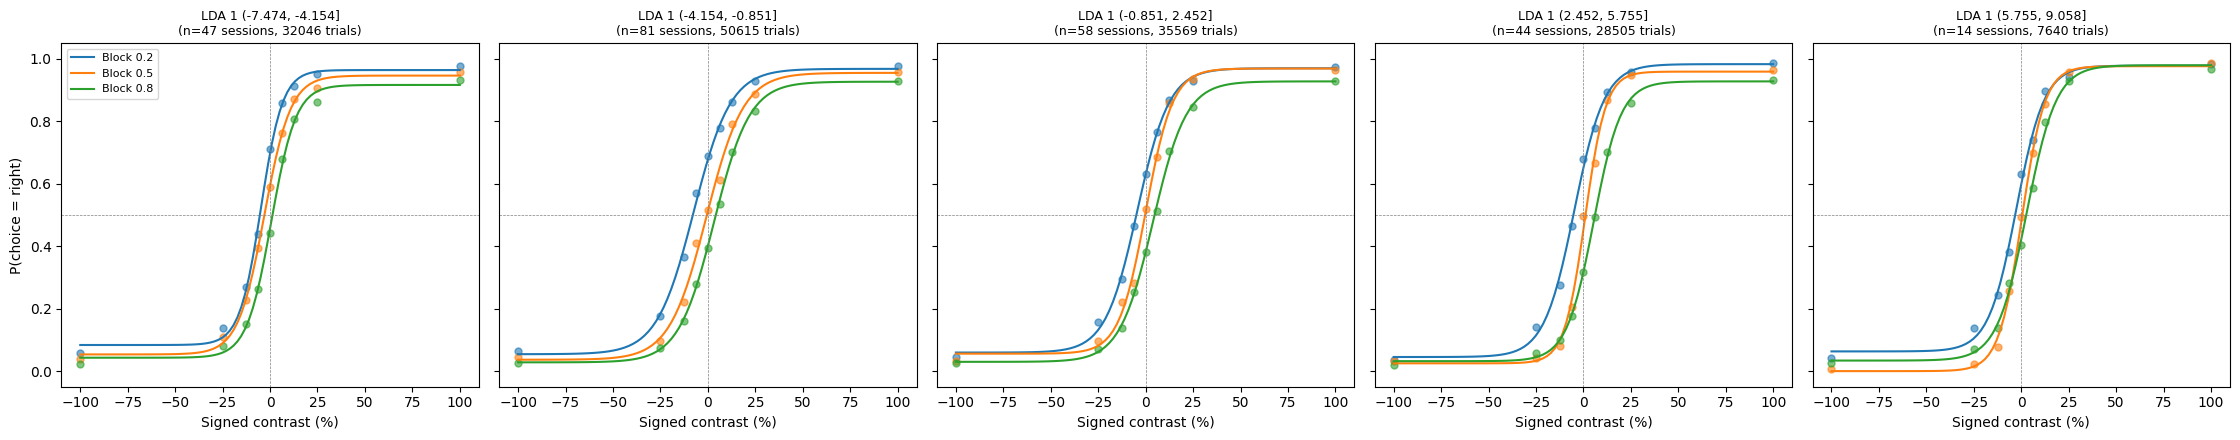

In [7]:
bin_order = sorted(trials['lda_bin'].cat.categories, key=lambda iv: iv.left)

fig, axes = plt.subplots(1, len(bin_order), figsize=(4.5 * len(bin_order), 4.5), sharey=True)
for ax, b in zip(axes, bin_order):
    bin_data = trials[trials['lda_bin'] == b]
    n_sessions = bin_data['eid'].nunique()
    n_trials = len(bin_data)
    plot_psychometric_bin(ax, bin_data, f'LDA 1 {b}\n(n={n_sessions} sessions, {n_trials} trials)')
axes[0].set_ylabel('P(choice = right)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Chronometric curves per LDA 1 bin

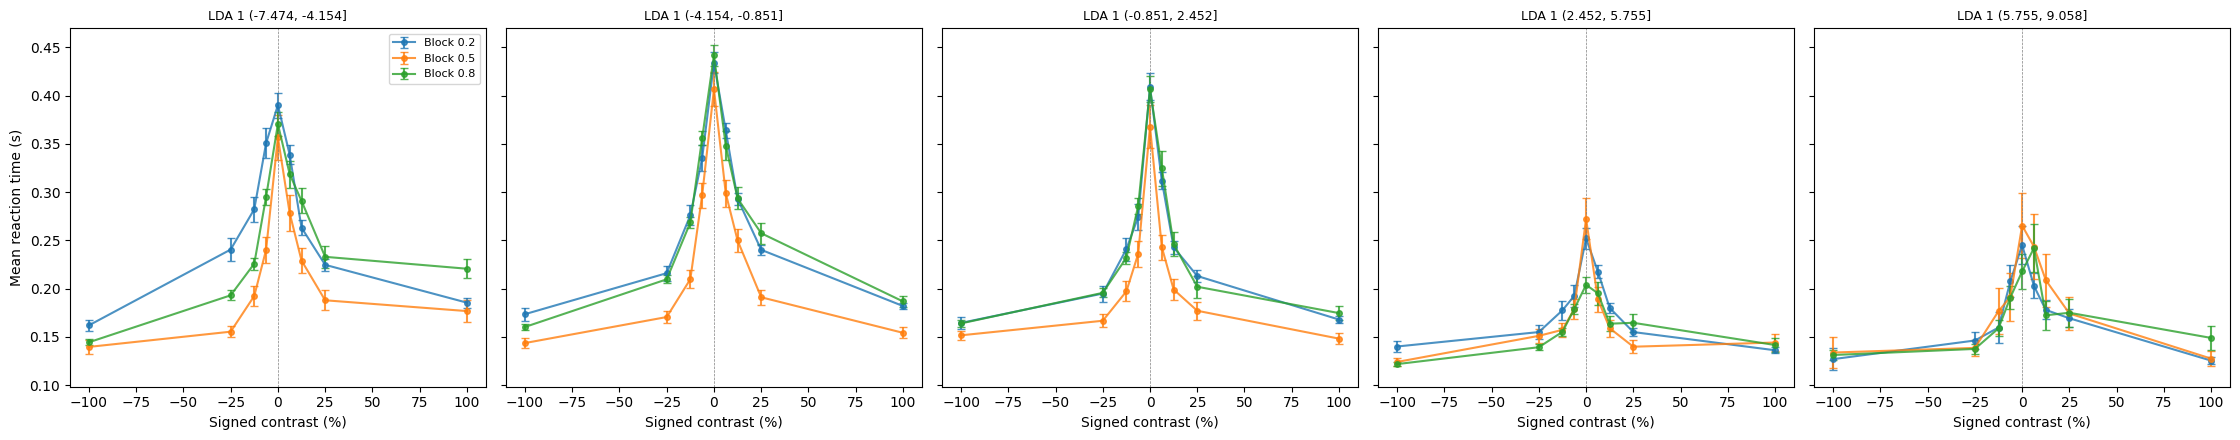

In [8]:
fig, axes = plt.subplots(1, len(bin_order), figsize=(4.5 * len(bin_order), 4.5), sharey=True)
for ax, b in zip(axes, bin_order):
    bin_data = trials[trials['lda_bin'] == b]
    plot_chronometric_bin(ax, bin_data, f'LDA 1 {b}')
axes[0].set_ylabel('Mean reaction time (s)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()